# Doping Clifford circuits

A Clifford circuit is efficiently simulable. *Doping* inserts non-Clifford `Z` rotations, either `T` gates or parametrized `RZ` gates, at wires where each one is irreducible ([arXiv:2607.25941](https://arxiv.org/abs/2607.25941), Sec. S1.3), making the circuit hard to simulate while leaving its Clifford skeleton, and any spacetime Pauli checks on it, intact. This guide shows each way `dope_clifford_circuit` can be used:

1. Dope every valid wire with `T` gates.
2. Dope a fixed number of wires.
3. Emit one parametrized `RZ` template covering every doping configuration.
4. Dope a checked circuit without disturbing its checks.

## 1. Build a Clifford circuit

Doping accepts any Clifford circuit whose measurements, if present, are terminal.

In [1]:
import numpy as np
from qiskit import QuantumCircuit

rng = np.random.default_rng(1764)
circuit = QuantumCircuit(10)
circuit.h(range(circuit.num_qubits))
for d in range(6):
    for i in range(d % 2, circuit.num_qubits - 1, 2):
        circuit.cz(i, i + 1)
    for q in range(circuit.num_qubits):
        if rng.integers(0, 2):
            circuit.sx(q)
        if rng.integers(0, 2):
            circuit.s(q)
circuit.measure_all()

## 2. Dope every valid wire

By default, every wire that survives the reference's pruning receives a `T`. Each `DopingSite` names the qubit and the index of the instruction the `T` follows (`None` for a qubit's input wire).

24 T gates, e.g. [DopingSite(qubit=0, after_instruction=0), DopingSite(qubit=1, after_instruction=1), DopingSite(qubit=2, after_instruction=2)]


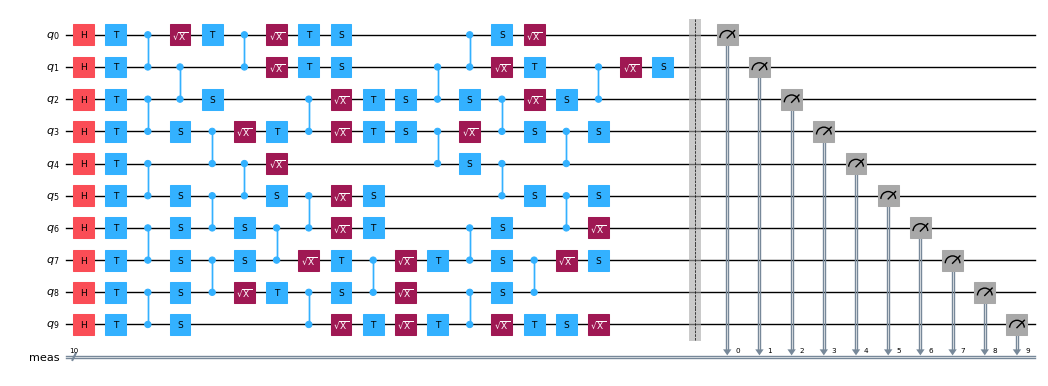

In [2]:
from qiskit_paulice import dope_clifford_circuit

doped, sites = dope_clifford_circuit(circuit)
print(f"{len(sites)} T gates, e.g. {sites[:3]}")
doped.draw("mpl", fold=-1, scale=0.5)

## 3. Dope a fixed number of wires

`num_sites` draws a random subset of the valid wires. Because a subset can itself be reducible, the draw is topped up until exactly that many irreducible `T` gates remain.

In [3]:
doped, sites = dope_clifford_circuit(circuit, num_sites=8, seed=1764)
print(sites)

[DopingSite(qubit=2, after_instruction=2), DopingSite(qubit=4, after_instruction=4), DopingSite(qubit=6, after_instruction=6), DopingSite(qubit=8, after_instruction=8), DopingSite(qubit=9, after_instruction=9), DopingSite(qubit=2, after_instruction=39), DopingSite(qubit=9, after_instruction=47), DopingSite(qubit=7, after_instruction=59)]


## 4. One parametrized template for every doping configuration

`parametric=True` inserts `rz(dope[i])` at site `i` in place of a `T`, so one circuit, and one pulse schedule, serves every configuration: $\pi/4$ is `T`, $\pi/2$ is `S`, $\pi$ is `Z`, and $0$ is the identity. `wires` selects the candidate wires: every wire segment by default, or only those directly following (`"after_entangling"`, as in the reference) or directly preceding (`"before_entangling"`) an entangling gate, one site per qubit per entangling layer.

21 parametrized sites


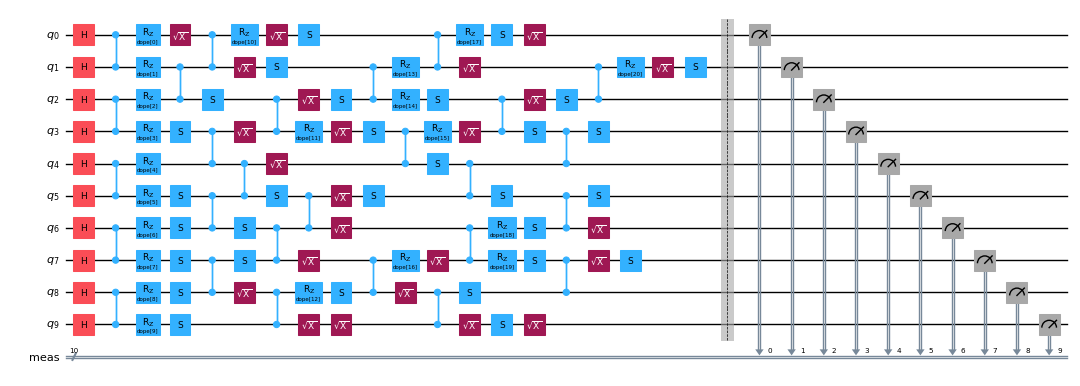

In [4]:
template, sites = dope_clifford_circuit(circuit, wires="after_entangling", parametric=True)
print(f"{len(sites)} parametrized sites")
template.draw("mpl", fold=-1, scale=0.5)

Bind angles to `dope` to pick a configuration; here each site becomes a `T` gate or the identity at random.

In [5]:
angles = rng.choice([0.0, np.pi / 4], size=len(sites))
configuration = template.assign_parameters(dict(zip(template.parameters, angles, strict=True)))
print(f"{np.count_nonzero(angles)} T gates in this configuration")

11 T gates in this configuration


## 5. Dope a checked circuit

Given a `CheckedCircuit`, doping is restricted to wires whose `Z` rotation commutes with every check, so all syndromes remain deterministic and postselection works exactly as before. A new `CheckedCircuit` with the same check metadata is returned; here we confirm that each check's syndrome is deterministic in the ideal output state of the doped circuit.

19 T gates preserve all 5 checks
check on qubits (1, 2, 10): <Z parity> = 1.000
check on qubits (1, 2, 4, 11): <Z parity> = 1.000
check on qubits (3, 5, 12): <Z parity> = 1.000
check on qubits (6, 13): <Z parity> = 1.000
check on qubits (14,): <Z parity> = 1.000


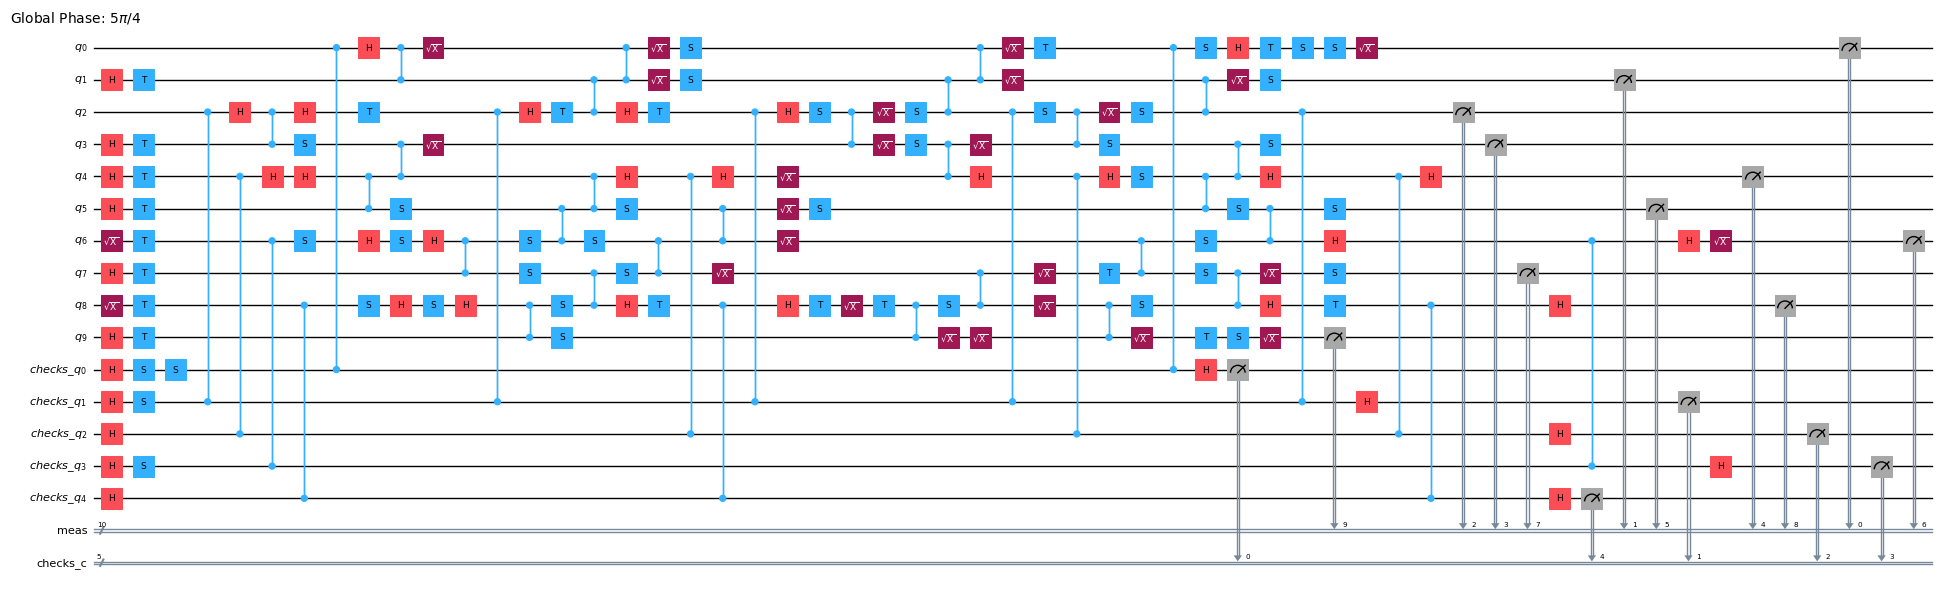

In [6]:
from qiskit.quantum_info import Pauli, Statevector
from qiskit_paulice import NoiseModel, add_pauli_checks

noise_model = NoiseModel(gate_noise=0.002, readout_noise=0.005)
checked = add_pauli_checks(
    circuit, target_qubits=[0, 2, 4, 6, 8], noise_model=noise_model, seed=1764
)[-1]

doped_checked, sites = dope_clifford_circuit(checked)
print(f"{len(sites)} T gates preserve all {len(checked.check_qubits)} checks")

# The Z parity over each check's support is +1 for every ideal output
state = Statevector(doped_checked.circuit.remove_final_measurements(inplace=False))
num_qubits = doped_checked.circuit.num_qubits
for support in doped_checked.check_support:
    parity = Pauli("".join("Z" if q in support else "I" for q in reversed(range(num_qubits))))
    print(f"check on qubits {support}: <Z parity> = {state.expectation_value(parity).real:.3f}")
doped_checked.circuit.draw("mpl", fold=-1, scale=0.5, idle_wires=False)